# Model Results

In [25]:
import numpy as np
import pandas as pd
from eda import transform_data, split
import models as mdls

In [26]:
seoul_bike_data = pd.read_csv("SeoulBikeData.csv", encoding = "unicode_escape")
seoul_bike_data = transform_data(seoul_bike_data)
X_train, X_test, Y_train, Y_test = split(seoul_bike_data)

## OLS Results

In [28]:
ols_model = mdls.train_ols(X_train, Y_train)
ols_performance = mdls.get_performance(ols_model, X_train, X_test, Y_train, Y_test)
mdls.clean_print_metrics(ols_performance)

Train Metrics
Parameters: None
RMSE: 0.3417
MAE: 0.2311
R²: 0.9151

Test Metrics
Parameters: None
RMSE: 571345973489.7428
MAE: 546516844879.0624
R²: -3.2317567399534406e+23


## K-Neighbors Regressor Results

In [30]:
knn_model, knn_best_params = mdls.train_knn(X_train, Y_train)
knn_performance = mdls.get_performance(knn_model, X_train, X_test, Y_train, Y_test, parameters = knn_best_params)
mdls.clean_print_metrics(knn_performance)

Train Metrics
Parameters: {'knn__n_neighbors': 7}
RMSE: 0.3098
MAE: 0.1946
R²: 0.9302

Test Metrics
Parameters: {'knn__n_neighbors': 7}
RMSE: 0.4506
MAE: 0.2964
R²: 0.799


## Elastic Net Results

In [32]:
elastic_net_model, elastic_net_best_params = mdls.train_elastic_net(X_train, Y_train)
elastic_net_performance = mdls.get_performance(elastic_net_model, X_train, X_test, Y_train, Y_test, parameters = elastic_net_best_params)
mdls.clean_print_metrics(elastic_net_performance)

Train Metrics
Parameters: {'elastic_net__alpha': 0.01, 'elastic_net__l1_ratio': 0.9}
RMSE: 0.35
MAE: 0.2373
R²: 0.9109

Test Metrics
Parameters: {'elastic_net__alpha': 0.01, 'elastic_net__l1_ratio': 0.9}
RMSE: 0.3676
MAE: 0.2375
R²: 0.8662


## Lasso Results

In [34]:
lasso_model, lasso_best_params = mdls.train_lasso(X_train, Y_train)
lasso_performance = mdls.get_performance(lasso_model, X_train, X_test, Y_train, Y_test, parameters = lasso_best_params)
mdls.clean_print_metrics(lasso_performance)

Train Metrics
Parameters: {'lasso__alpha': 0.01}
RMSE: 0.3507
MAE: 0.238
R²: 0.9106

Test Metrics
Parameters: {'lasso__alpha': 0.01}
RMSE: 0.3681
MAE: 0.2382
R²: 0.8659


## Ridge Results

In [36]:
ridge_model, ridge_best_params = mdls.train_ridge(X_train, Y_train)
ridge_performance = mdls.get_performance(ridge_model, X_train, X_test, Y_train, Y_test, parameters = ridge_best_params)
mdls.clean_print_metrics(ridge_performance)

Train Metrics
Parameters: {'ridge__alpha': 5.0}
RMSE: 0.3414
MAE: 0.2306
R²: 0.9152

Test Metrics
Parameters: {'ridge__alpha': 5.0}
RMSE: 0.3963
MAE: 0.2895
R²: 0.8445


## SGD Regressor Results

In [38]:
sgd_model, sgd_best_params = mdls.train_sgd(X_train, Y_train)
sgd_performance = mdls.get_performance(sgd_model, X_train, X_test, Y_train, Y_test, parameters = sgd_best_params)
mdls.clean_print_metrics(sgd_performance)

Train Metrics
Parameters: {'sgd__alpha': 0.1, 'sgd__penalty': 'l1'}
RMSE: 0.4041
MAE: 0.2975
R²: 0.8813

Test Metrics
Parameters: {'sgd__alpha': 0.1, 'sgd__penalty': 'l1'}
RMSE: 0.4161
MAE: 0.3006
R²: 0.8286


## Results Comparison

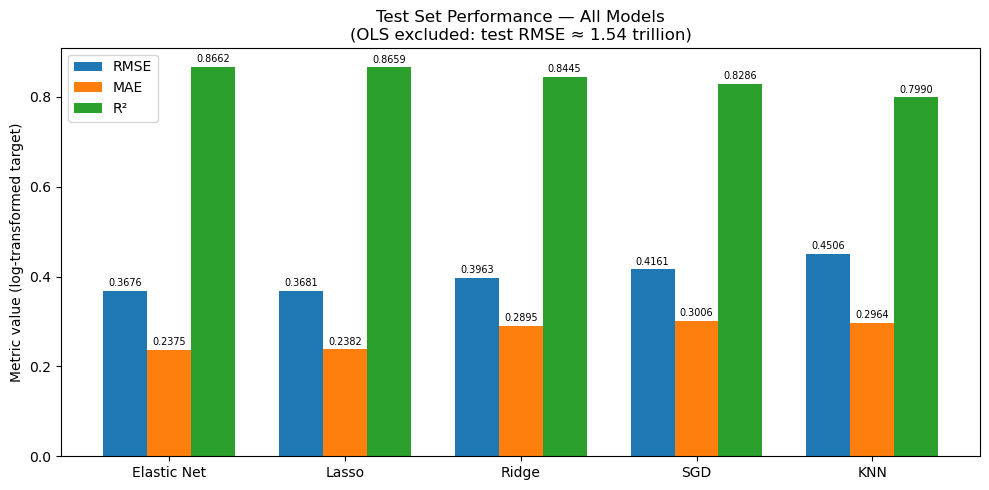

In [40]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Elastic Net", "Lasso", "Ridge", "SGD", "KNN"]

test_rmse = [elastic_net_performance["Test"]["RMSE"],
             lasso_performance["Test"]["RMSE"],
             ridge_performance["Test"]["RMSE"],
             sgd_performance["Test"]["RMSE"],
             knn_performance["Test"]["RMSE"]]

test_mae  = [elastic_net_performance["Test"]["MAE"],
             lasso_performance["Test"]["MAE"],
             ridge_performance["Test"]["MAE"],
             sgd_performance["Test"]["MAE"],
             knn_performance["Test"]["MAE"]]

test_r2   = [elastic_net_performance["Test"]["R\u00b2"],
             lasso_performance["Test"]["R\u00b2"],
             ridge_performance["Test"]["R\u00b2"],
             sgd_performance["Test"]["R\u00b2"],
             knn_performance["Test"]["R\u00b2"]]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - w, test_rmse, w, label="RMSE")
ax.bar(x,     test_mae,  w, label="MAE")
ax.bar(x + w, test_r2,   w, label="R\u00b2")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Metric value (log-transformed target)")
ax.set_title("Test Set Performance — All Models\n(OLS excluded: test RMSE \u2248 1.54 trillion)")
ax.legend()
ax.axhline(0, color="black", linewidth=0.6)

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.4f", fontsize=7, padding=2)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()